In [225]:
import pandas as pd

# Beyond Blue dataset (already enriched with valence/arousal/emotion)
bb = pd.read_csv("data/beyondblue_data_flattened_transformers_twitter_english_enriched.csv")
bb['date'] = pd.to_datetime(bb['date'], errors='coerce')

# Natural disaster dataset
nd = pd.read_csv("data/natural_disaster_data_cleaned.csv")
nd['start_date'] = pd.to_datetime(nd['start_date'])
nd['end_date'] = pd.to_datetime(nd['end_date'])

In [226]:
bb.head()

,parent_post_id,user_id,role,text,date,category,sentiment_dist,valence_s,sentiment_top,sentiment_conf,emotion_dist,valence_e,arousal_e,emotion_top,emotion_conf
0,1,Toby,original,"Struggling at the moment. Hello everyone, this...",2025-07-16,Anxiety,"{'NEGATIVE': 0.6358407139778137, 'NEUTRAL': 0....",-0.573183,NEGATIVE,0.635841,"{'anger': 0.0030326072592288256, 'disgust': 0....",0.079505,0.828274,fear,0.969302
1,1,Morph,commenter,"Hi Toby, welcome and congratulations on your f...",2025-07-17,Anxiety,"{'NEGATIVE': 0.002651855116710067, 'NEUTRAL': ...",0.971309,POSITIVE,0.973961,"{'anger': 0.0023175962269306183, 'disgust': 0....",0.877638,0.714559,joy,0.780846
2,1,AudaciousPoodle,commenter,"Hi Toby, Reading your post sounds just like wh...",2025-07-17,Anxiety,"{'NEGATIVE': 0.7963150143623352, 'NEUTRAL': 0....",-0.754034,NEGATIVE,0.796315,"{'anger': 0.010348315350711346, 'disgust': 0.0...",0.071904,0.324703,sadness,0.913931
3,1,_Gigi_,commenter,"Hello Toby,I'm glad you've decided to reach ou...",2025-07-18,Anxiety,"{'NEGATIVE': 0.01175833772867918, 'NEUTRAL': 0...",0.903619,POSITIVE,0.915377,"{'anger': 0.0013056608149781823, 'disgust': 0....",0.867446,0.751704,joy,0.845598
4,1,Toby,op_reply,My anxiety is affecting my whole life. When I ...,2025-07-18,Anxiety,"{'NEGATIVE': 0.6501989364624023, 'NEUTRAL': 0....",-0.580363,NEGATIVE,0.650199,"{'anger': 0.010438608936965466, 'disgust': 0.0...",0.253667,0.546303,sadness,0.477066


In [227]:
import re

def clean_disaster_list(x):
    if pd.isna(x):
        return []
    # remove brackets and split
    items = re.sub(r'[\[\]\']', '', x).split(',')
    items = [i.strip().lower() for i in items]
    return items

nd['disaster_types'] = nd['disaster_types'].apply(clean_disaster_list)

# normalisation mapping
normalize = {
    "bushfire": "bushfire",
    "flood": "flood",
    "cyclone": "cyclone",
}

def normalize_types(lst):
    return [normalize.get(i, i) for i in lst]

nd['disaster_types'] = nd['disaster_types'].apply(normalize_types)

In [228]:
nd_expanded = nd.explode("disaster_types").reset_index(drop=True)
nd_expanded.head()

,agrn,state,start_date,end_date,duration_days,disaster_types
0,872,QLD,2019-02-12,2019-02-21,10.0,bushfire
1,850,WA,2019-03-23,2019-03-26,4.0,cyclone
2,870,QLD,2019-09-06,2019-09-12,7.0,bushfire
3,909,QLD,2019-09-15,2019-10-15,31.0,bushfire
4,879,QLD,2019-09-17,2019-09-24,8.0,bushfire


In [229]:
from datetime import timedelta

def align_disaster(row, bb_date):
    start = row['start_date']
    end = row['end_date']
    
    pre_start = start - timedelta(days=15)
    post_end = end + timedelta(days=15)

    if pre_start <= bb_date < start:
        return "pre"
    elif start <= bb_date <= end:
        return "during"
    elif end < bb_date <= post_end:
        return "post"
    else:
        return None

In [230]:
aligned_rows = []

for _, post in bb.iterrows():
    post_date = post['date']
    if pd.isna(post_date):
        continue

    matches = nd_expanded[
        (nd_expanded['start_date'] - pd.Timedelta(days=30) <= post_date) &
        (post_date <= nd_expanded['end_date'] + pd.Timedelta(days=30))
    ]

    if len(matches) == 0:
        continue

    for _, d in matches.iterrows():
        aligned_rows.append({
            "bb_id": post['parent_post_id'],
            "user_id": post['user_id'],
            "bb_date": post['date'],
            "disaster_type": d['disaster_types'],
            "disaster_state": d['state'],
            "phase": align_disaster(d, post_date),
            "valence": post['valence_e'],
            "arousal": post['arousal_e'],
            "emotion_top": post['emotion_top'],
            "duration_days": d['duration_days']
        })

aligned = pd.DataFrame(aligned_rows)
aligned.head()

,bb_id,user_id,bb_date,disaster_type,disaster_state,phase,valence,arousal,emotion_top,duration_days
0,17,Whatsinaname,2020-09-25,bushfire,NT,post,0.272267,0.689516,fear,50.0
1,17,Whatsinaname,2020-09-25,bushfire,QLD,None,0.272267,0.689516,fear,8.0
2,17,uncut_gems,2020-09-25,bushfire,NT,post,0.752378,0.760550,joy,50.0
3,17,uncut_gems,2020-09-25,bushfire,QLD,None,0.752378,0.760550,joy,8.0
4,17,Whatsinaname,2020-09-25,bushfire,NT,post,0.768758,0.591071,joy,50.0


In [231]:
# show aligned data shape
print("Aligned data shape:", aligned.shape)

Aligned data shape: (105713, 10)


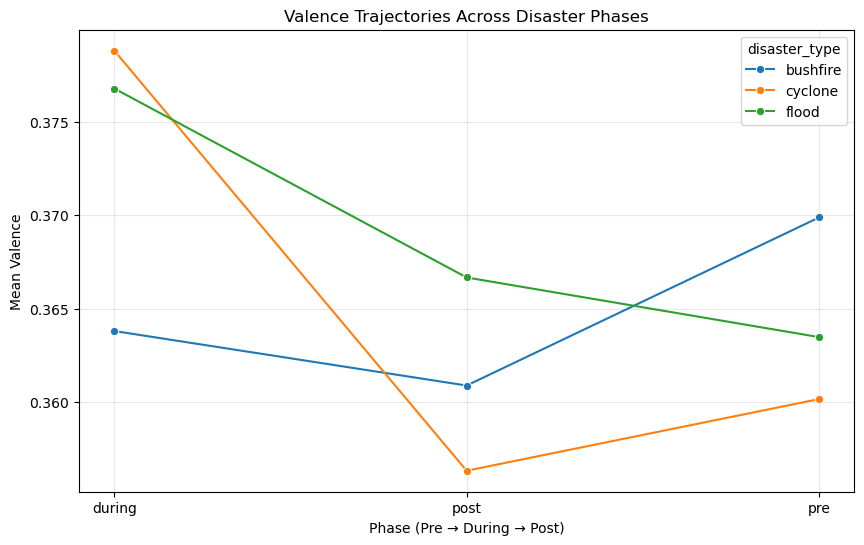

In [232]:
val_curve = aligned.groupby(['disaster_type','phase'])['valence'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(data=val_curve, x='phase', y='valence', hue='disaster_type', marker='o')
plt.title("Valence Trajectories Across Disaster Phases")
plt.xlabel("Phase (Pre → During → Post)")
plt.ylabel("Mean Valence")
plt.grid(True, alpha=0.3)
plt.show()

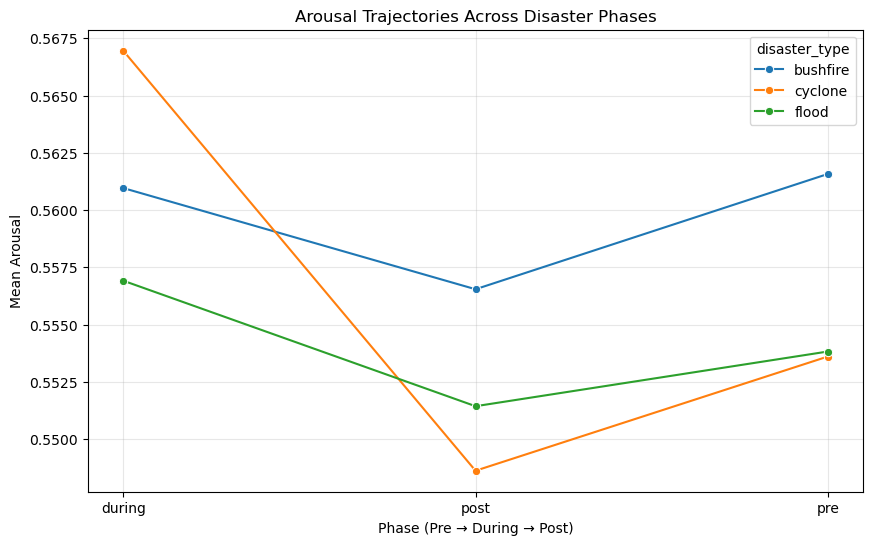

In [233]:
aro_curve = aligned.groupby(['disaster_type','phase'])['arousal'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=aro_curve, x='phase', y='arousal', hue='disaster_type', marker='o')
plt.title("Arousal Trajectories Across Disaster Phases")
plt.xlabel("Phase (Pre → During → Post)")
plt.ylabel("Mean Arousal")
plt.grid(True, alpha=0.3)
plt.show()

In [234]:
shift = aligned.groupby(['disaster_type','phase'])[['valence','arousal']].mean().unstack()
shift

valence                       arousal                    
phase            during      post       pre    during      post       pre
disaster_type                                                            
bushfire       0.363801  0.360885  0.369876  0.560961  0.556541  0.561576
cyclone        0.378799  0.356327  0.360159  0.566960  0.548614  0.553601
flood          0.376775  0.366666  0.363477  0.556914  0.551432  0.553821

In [235]:
import numpy as np
import pandas as pd

disaster_shifts = []

for d, g in aligned.groupby('disaster_type'):
    
    # ---- Valence ----
    pre_val = g[g['phase']=='pre']['valence'].mean()
    dur_val = g[g['phase']=='during']['valence'].mean()
    post_val = g[g['phase']=='post']['valence'].mean()

    # ---- Arousal ----
    pre_aro = g[g['phase']=='pre']['arousal'].mean()
    dur_aro = g[g['phase']=='during']['arousal'].mean()
    post_aro = g[g['phase']=='post']['arousal'].mean()
    
    disaster_shifts.append({
        'disaster_type': d,

        # Valence shifts
        'val_pre_to_during': dur_val - pre_val,
        'val_during_to_post': post_val - dur_val,

        # Arousal shifts
        'aro_pre_to_during': dur_aro - pre_aro,
        'aro_during_to_post': post_aro - dur_aro
    })

shift_df = pd.DataFrame(disaster_shifts)
shift_df

,disaster_type,val_pre_to_during,val_during_to_post,aro_pre_to_during,aro_during_to_post
0,bushfire,-0.006075,-0.002916,-0.000615,-0.004420
1,cyclone,0.018641,-0.022473,0.013359,-0.018346
2,flood,0.013298,-0.010108,0.003093,-0.005482


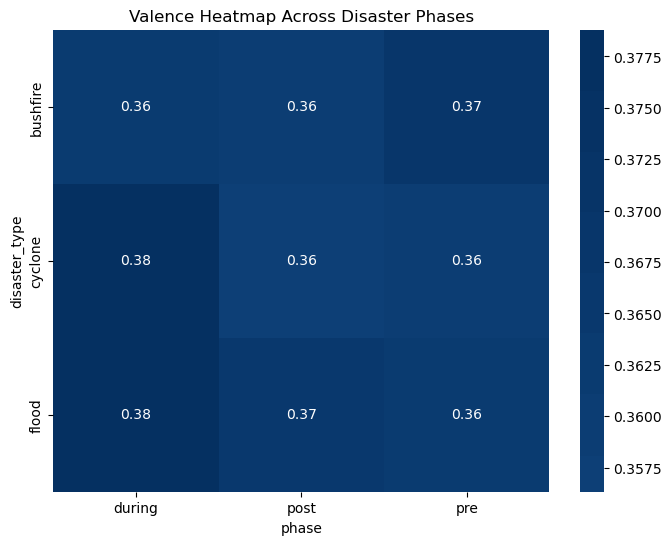

In [236]:
pivot = aligned.pivot_table(
    index='disaster_type',
    columns='phase',
    values='valence',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="RdBu", center=0)
plt.title("Valence Heatmap Across Disaster Phases")
plt.show()

In [237]:
# Save the aligned dataset
aligned.to_csv("data/beyondblue_x_natural_disaster_data_aligned.csv", index=False)

In [238]:
def classify_severity(d):
    if pd.isna(d):
        return None      # in case of any missing
    if d <= 3:
        return "short"
    elif d <= 10:
        return "medium"
    else:
        return "long"

aligned['severity'] = aligned['duration_days'].apply(classify_severity)

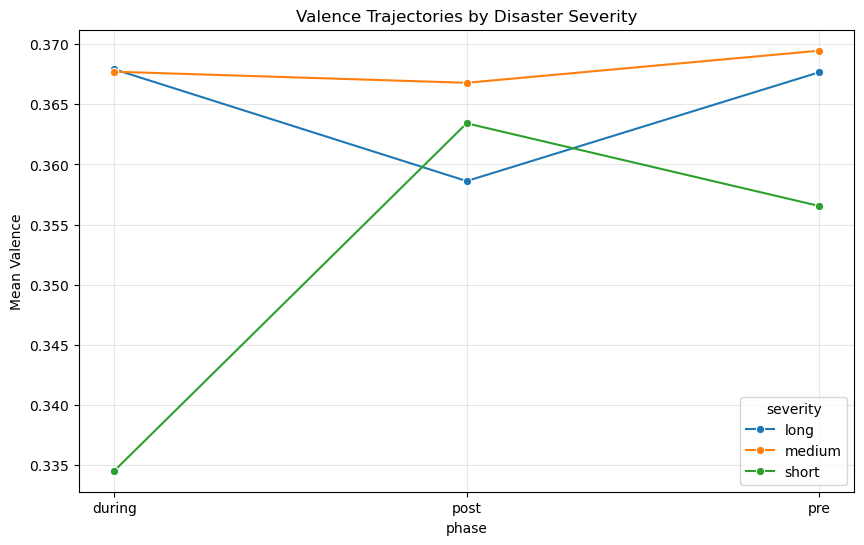

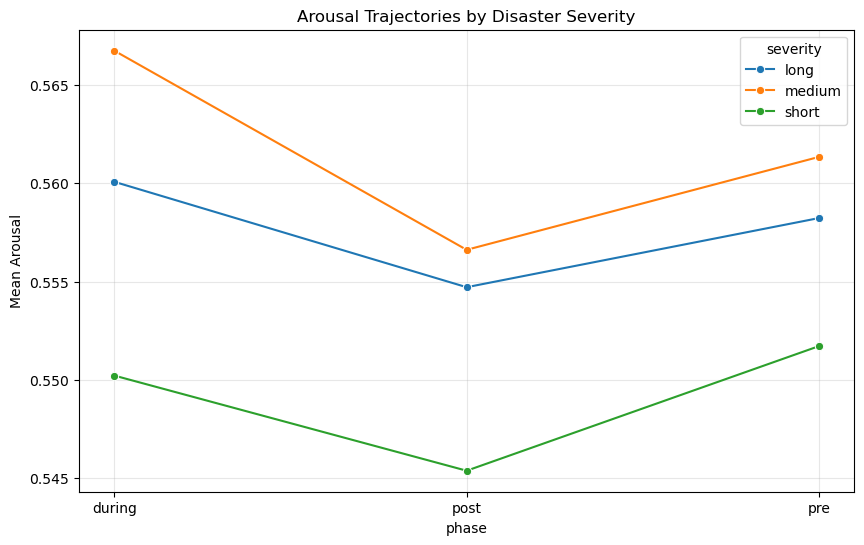

In [239]:
phase_curve = aligned.groupby(['severity','phase'])[['valence','arousal']].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=phase_curve,
    x='phase',
    y='valence',
    hue='severity',
    marker='o'
)
plt.title("Valence Trajectories by Disaster Severity")
plt.ylabel("Mean Valence")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=phase_curve,
    x='phase',
    y='arousal',
    hue='severity',
    marker='o'
)
plt.title("Arousal Trajectories by Disaster Severity")
plt.ylabel("Mean Arousal")
plt.grid(True, alpha=0.3)
plt.show()

In [240]:
severity_shift = []

for sev, g in aligned.groupby("severity"):
    pre = g[g['phase']=="pre"]['valence'].mean()
    dur = g[g['phase']=="during"]['valence'].mean()
    post = g[g['phase']=="post"]['valence'].mean()

    severity_shift.append({
        'severity': sev,
        'pre_to_during': dur - pre,
        'during_to_post': post - dur
    })

severity_shift_df = pd.DataFrame(severity_shift)
print(severity_shift_df)

  severity  pre_to_during  during_to_post
0     long       0.000252       -0.009294
1   medium      -0.001744       -0.000924
2    short      -0.022025        0.028897


#### Interrupted Time Series Model


 Running ITS for BUSHFIRE



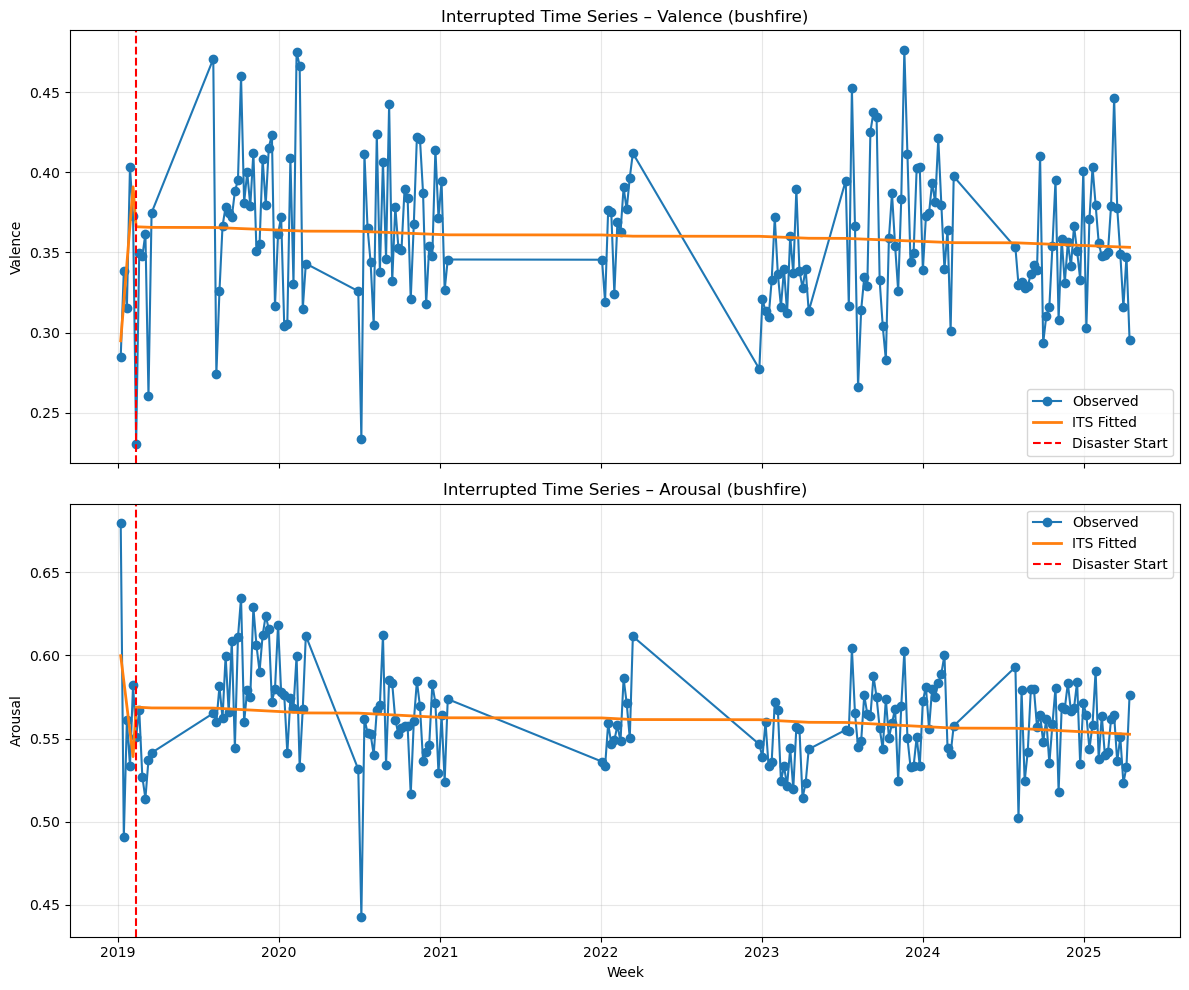


 Running ITS for FLOOD



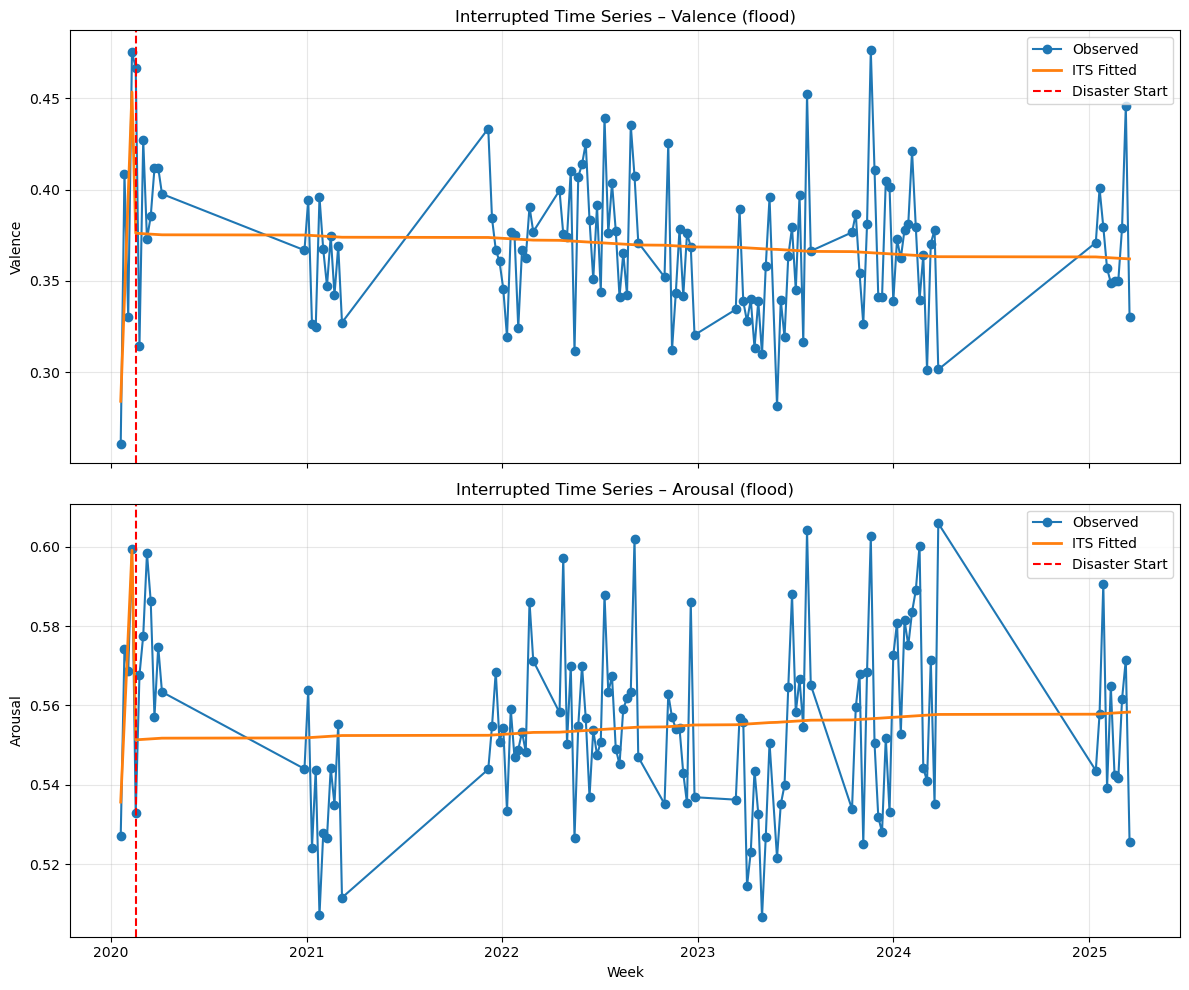


 Running ITS for CYCLONE



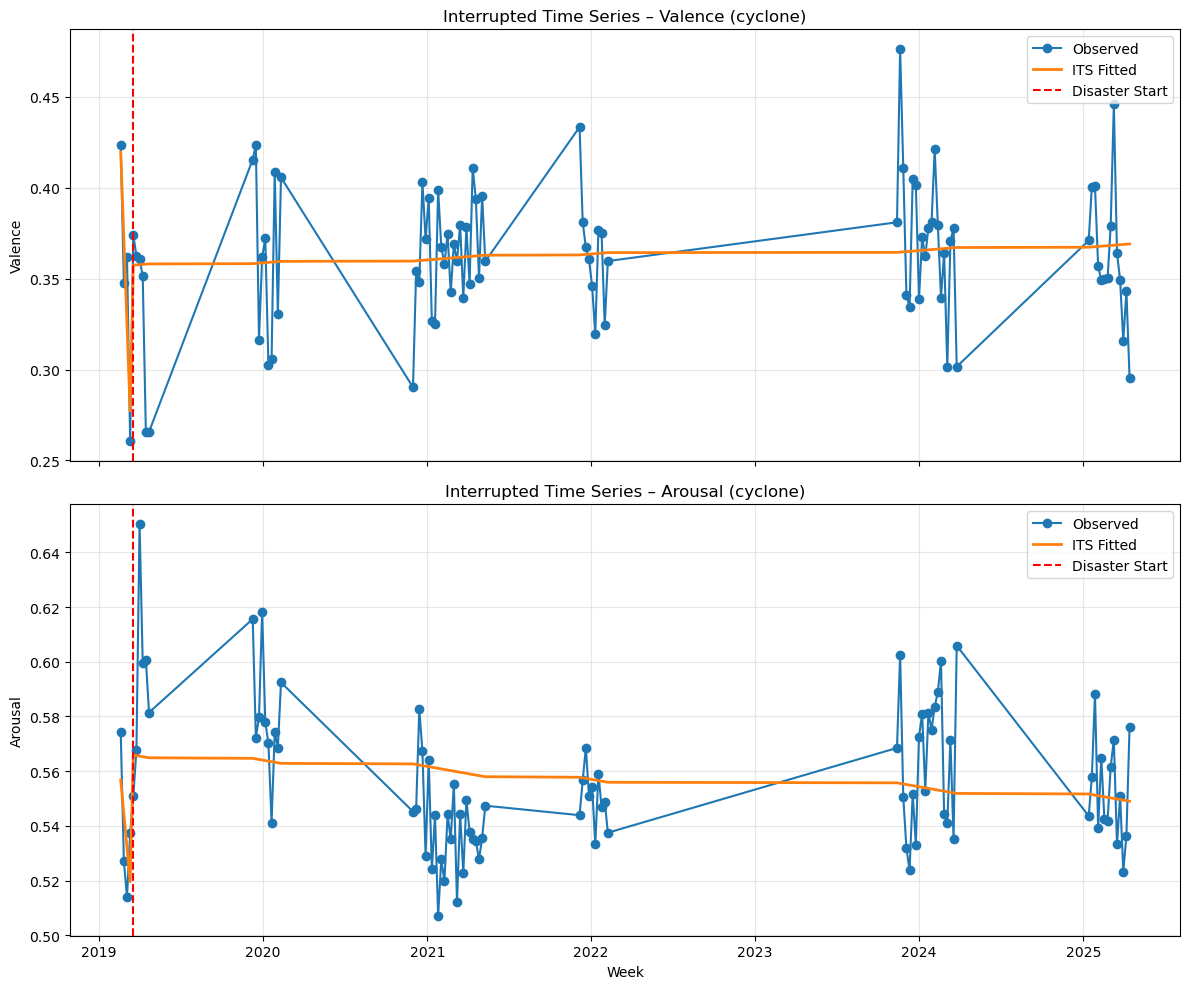


ITS completed for all applicable disaster types.


In [255]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ==========================
#  1. Load aligned dataset
# ==========================
df = aligned.copy()
df['bb_date'] = pd.to_datetime(df['bb_date'], errors='coerce')

# Keep only disasters with enough data
disaster_list = df['disaster_type'].dropna().unique()

results = {}   # to store ITS outputs


# =========================================================
#  FUNCTION: Run ITS for a single disaster type
# =========================================================
def run_its(dis_type, df):

    sub = df[df['disaster_type'] == dis_type].copy()
    if len(sub) < 30:
        print(f"⚠ Skipping {dis_type} — too few aligned posts.\n")
        return None
    
    # ---- Weekly aggregation ----
    sub['week'] = sub['bb_date'].dt.to_period('W').dt.to_timestamp()
    weekly = sub.groupby("week")[["valence", "arousal"]].mean().reset_index()

    if len(weekly) < 10:
        print(f"⚠ Skipping {dis_type} — insufficient weekly data.\n")
        return None

    # ---- Time index ----
    weekly['t'] = np.arange(len(weekly))

    # ---- Intervention week = earliest week with phase=="during" ----
    start_date = sub[sub['phase']=="during"]['bb_date'].min()
    if pd.isna(start_date):
        print(f"⚠ Skipping {dis_type} — no 'during' phase found.\n")
        return None

    start_week = start_date.to_period("W").start_time

    weekly['intervention'] = (weekly['week'] >= start_week).astype(int)

    # ---- Slope after event ----
    weekly['t_post'] = weekly['t'] * weekly['intervention']

    # -------------------------
    #     ITS Model (Valence)
    # -------------------------
    X = sm.add_constant(weekly[['t','intervention','t_post']])
    y_val = weekly['valence']

    model_val = sm.OLS(y_val, X).fit(cov_type="HAC", cov_kwds={"maxlags":3})
    weekly['val_pred'] = model_val.predict(X)

    # -------------------------
    #     ITS Model (Arousal)
    # -------------------------
    y_aro = weekly['arousal']
    model_aro = sm.OLS(y_aro, X).fit(cov_type="HAC", cov_kwds={"maxlags":3})
    weekly['aro_pred'] = model_aro.predict(X)

    # -------------------------
    #     Plot with trendlines
    # -------------------------
    fig, axes = plt.subplots(2, 1, figsize=(12,10), sharex=True)

    # ---- VALENCE ----
    axes[0].plot(weekly['week'], weekly['valence'], marker='o', label="Observed")
    axes[0].plot(weekly['week'], weekly['val_pred'], linewidth=2, label="ITS Fitted")

    axes[0].axvline(start_week, color="red", linestyle="--", label="Disaster Start")

    axes[0].set_title(f"Interrupted Time Series – Valence ({dis_type})")
    axes[0].set_ylabel("Valence")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # ---- AROUSAL ----
    axes[1].plot(weekly['week'], weekly['arousal'], marker='o', label="Observed")
    axes[1].plot(weekly['week'], weekly['aro_pred'], linewidth=2, label="ITS Fitted")

    axes[1].axvline(start_week, color="red", linestyle="--", label="Disaster Start")

    axes[1].set_title(f"Interrupted Time Series – Arousal ({dis_type})")
    axes[1].set_ylabel("Arousal")
    axes[1].set_xlabel("Week")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "valence_model": model_val,
        "arousal_model": model_aro,
        "weekly_data": weekly,
        "start_week": start_week
    }


# =========================================================
#     RUN ITS FOR EACH DISASTER TYPE
# =========================================================
for d_type in disaster_list:
    print(f"\n==============================")
    print(f" Running ITS for {d_type.upper()}")
    print(f"==============================\n")

    out = run_its(d_type, df)
    if out is not None:
        results[d_type] = out

print("\nITS completed for all applicable disaster types.")

### Interrupted time–series results (bushfire, flood, cyclone)

The figures above show weekly mean **valence** and **arousal** for Beyond Blue posts
that fall within ±30 days of each national-scale disaster, together with an
interrupted time–series (ITS) fit.

---

#### 1. Overall pattern

- Across **all three disaster types**, the **ITS fitted line is almost flat** for
  both valence and arousal.
- The **red dashed line** (first “during” week) does **not coincide with a clear
  step change** or obvious shift in slope in the observed series.
- Instead, we mostly see **high week-to-week variability** around a relatively
  stable baseline.

This suggests that, at the *national* level, emotional tone in Beyond Blue posts
does **not exhibit a strong, abrupt discontinuity** at the start of these
disaster periods.

---

#### 2. Bushfire

- **Valence**: fluctuates between roughly 0.30–0.45 with no obvious jump at the
  intervention point. The ITS line is almost horizontal → estimated change in
  level and slope is very small.
- **Arousal**: slightly elevated around the disaster onset but again the fitted
  trend is nearly flat, with only a mild downward drift over time.

**Interpretation:** bushfires may coincide with *local* spikes in emotional
expression, but when averaged across all Beyond Blue posts the impact is weak
and quickly drowned by background variability.

---

#### 3. Flood

- **Valence**: shows noise and a few positive peaks, but the fitted line is
  close to constant before and after the flood onset.
- **Arousal**: some short-term spikes around the disaster period, yet the ITS
  fit again indicates only a tiny change in slope.

**Interpretation:** floods do not appear to create a sustained shift in the
overall emotional climate on the forum; any signal is small compared with
ongoing week-to-week fluctuations.

---

#### 4. Cyclone

- **Valence**: noisy but centred around a similar mean before and after the
  cyclone intervention line. No clear “step up” or “step down”.
- **Arousal**: slightly higher early in the series, with a gentle decline over
  time; the ITS line captures this small negative slope but not a sharp break
  at the cyclone start.

**Interpretation:** cyclones may be associated with slightly higher arousal in
the early period, but the model does **not** detect a strong interruption at
the defined start week.

---

#### 5. What this means for the thesis

- The ITS analysis is **consistent across disaster types**:  
  – **No large, abrupt level change** in valence or arousal at disaster onset.  
  – **Slope changes are tiny** relative to random variation.
- This fits your supervisor’s concern: at a **national aggregation**, the
  disaster signal is likely **diluted** by many unrelated posts and by people
  living outside the affected regions.
- Methodologically, you can still **use these ITS plots as evidence** that:
  1. You attempted a principled quasi-experimental design (beyond simple
     pre/post means);  
  2. Under current data and assumptions, **large population-level shifts are
     not supported**.

The ITS models *did not reveal strong intervention effects*, which motivates treating these disaster results as exploratory and emphasising the individual-trajectory and category-specific analyses where clearer patterns appear.